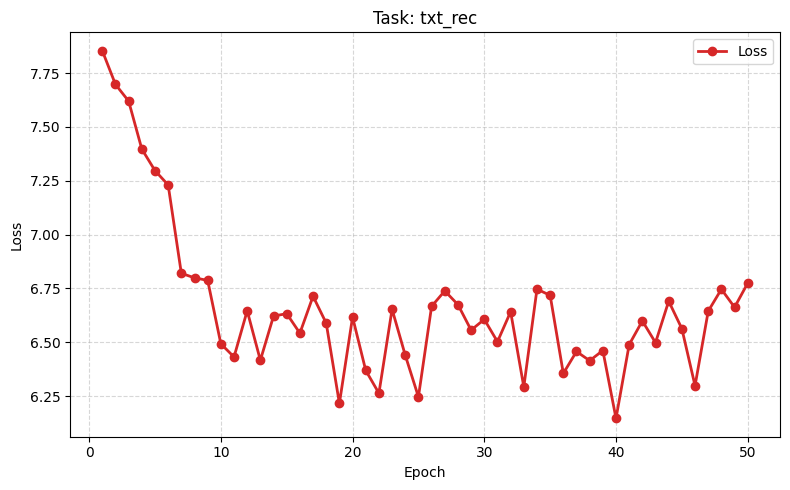

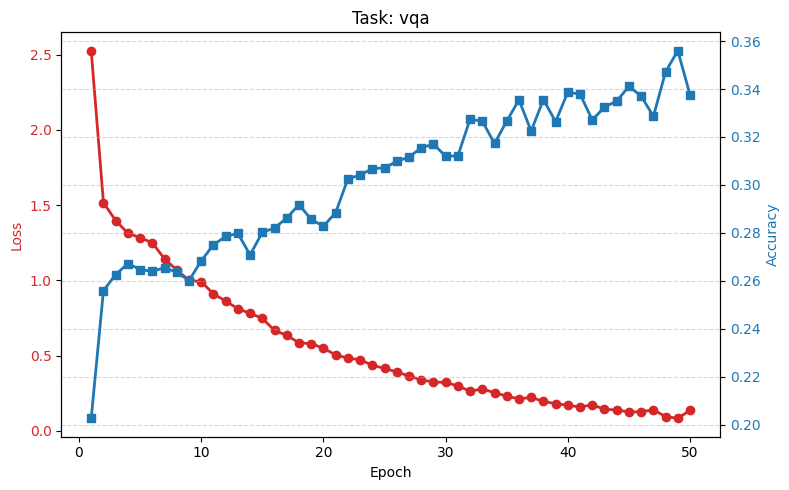

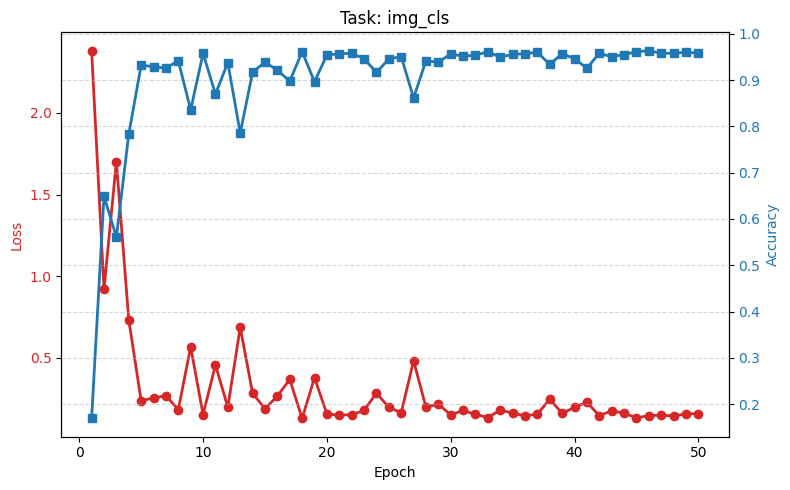

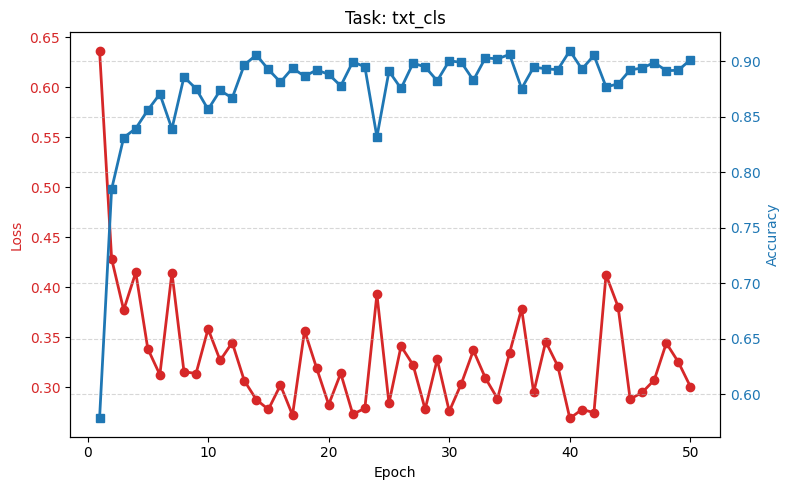

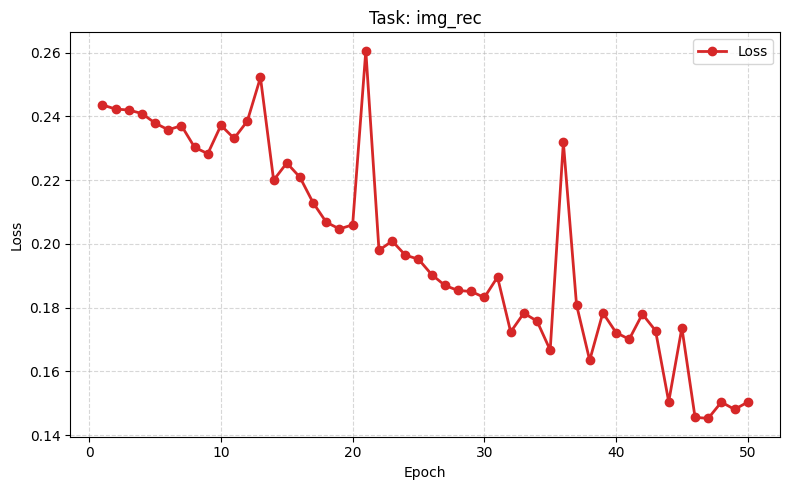

In [1]:
import re
import matplotlib.pyplot as plt

with open('./log/main_batch64_20260518_133357.log', 'r') as f:
    content = f.read()

# Clean up any potential artifacts like if present in the raw text
content = re.sub(r'\\s*', '', content)

metrics = {
    'txt_rec': {'loss': []},
    'vqa': {'loss': [], 'acc': []},
    'img_cls': {'loss': [], 'acc': []},
    'txt_cls': {'loss': [], 'acc': []},
    'img_rec': {'loss': []}
}

# Find all Evaluation blocks
eval_blocks = re.findall(r'Eval results:(.*?)(?===== Epoch|$)', content, re.DOTALL)

for block in eval_blocks:
    for task in metrics.keys():
        # Match from the task name to either the next task name, or end of block
        task_regex = rf'{task}:(.*?)(?=\n\s*\w+:|$)'
        task_chunk = re.search(task_regex, block, re.DOTALL)
        
        if task_chunk:
            chunk_str = task_chunk.group(1)
            loss_m = re.search(r'loss\s*=\s*([\d\.]+)', chunk_str)
            if loss_m:
                metrics[task]['loss'].append(float(loss_m.group(1)))
                
            if 'acc' in metrics[task]:
                acc_m = re.search(r'acc\s*=\s*([\d\.]+)', chunk_str)
                if acc_m:
                    metrics[task]['acc'].append(float(acc_m.group(1)))

# Generate a plot for each task
for task, data in metrics.items():
    epochs = range(1, len(data['loss']) + 1)
    
    # Skip if no data
    if len(epochs) == 0:
        continue
        
    if 'acc' in data and len(data['acc']) > 0:
        fig, ax1 = plt.subplots(figsize=(8, 5))

        color = 'tab:red'
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color=color)
        ax1.plot(epochs, data['loss'], color=color, marker='o', label='Loss', linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()  
        color = 'tab:blue'
        ax2.set_ylabel('Accuracy', color=color)  
        ax2.plot(epochs, data['acc'], color=color, marker='s', label='Accuracy', linewidth=2)
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title(f'Task: {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        fig.tight_layout()
        # plt.savefig(f'{task}_eval_results.png', dpi=150)
        plt.show()
        # plt.close(fig)
        
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, data['loss'], color='tab:red', marker='o', label='Loss', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Task: {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        # plt.savefig(f'{task}_eval_results.png', dpi=150)
        plt.show()
        # plt.close()

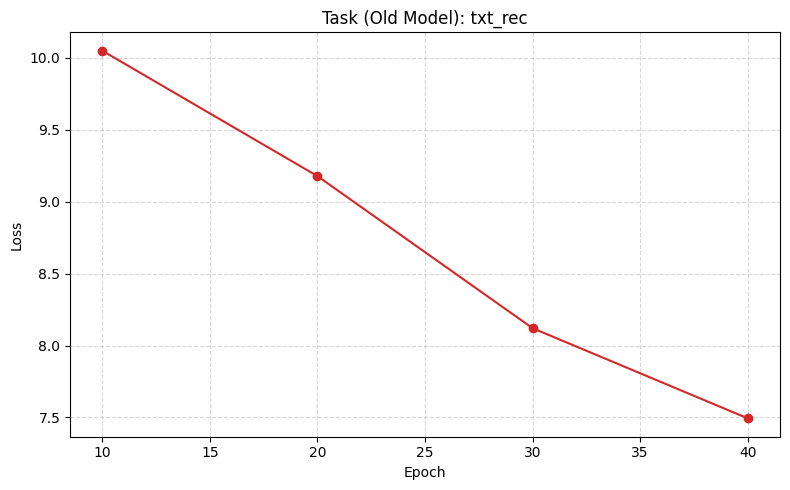

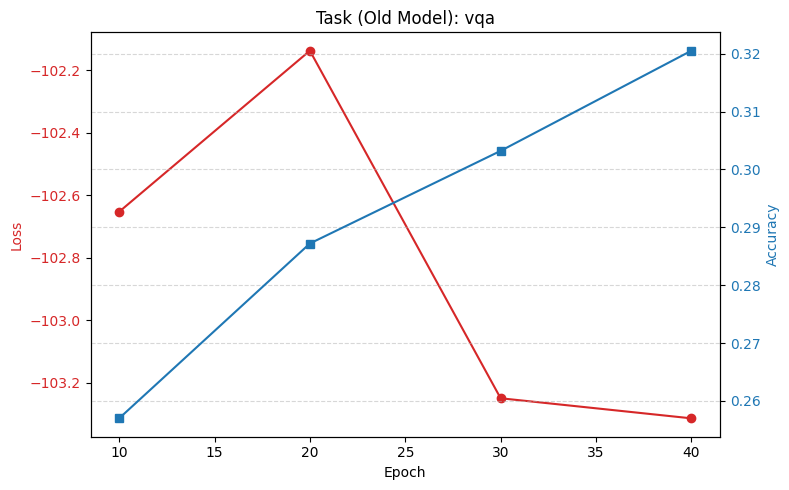

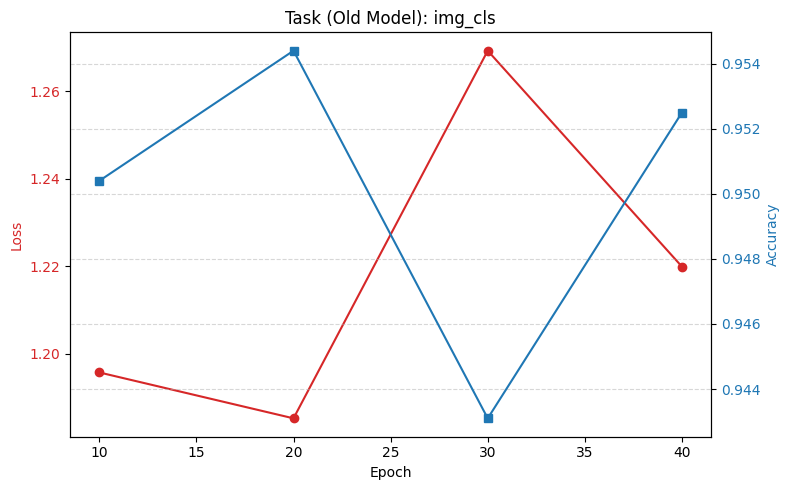

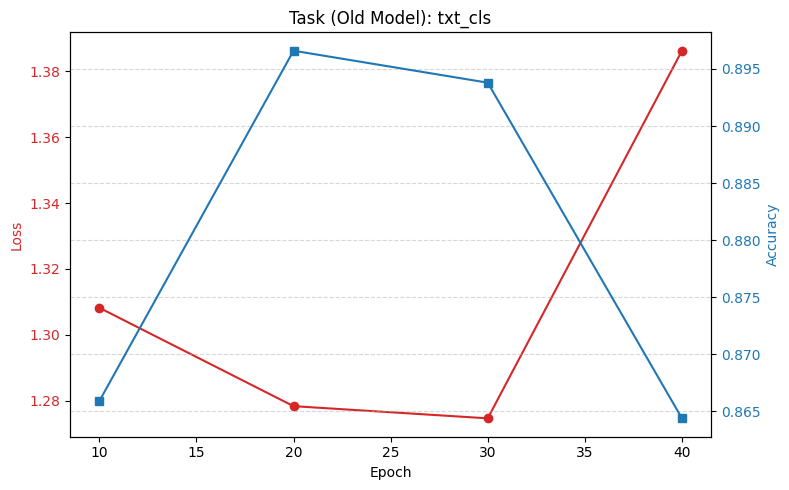

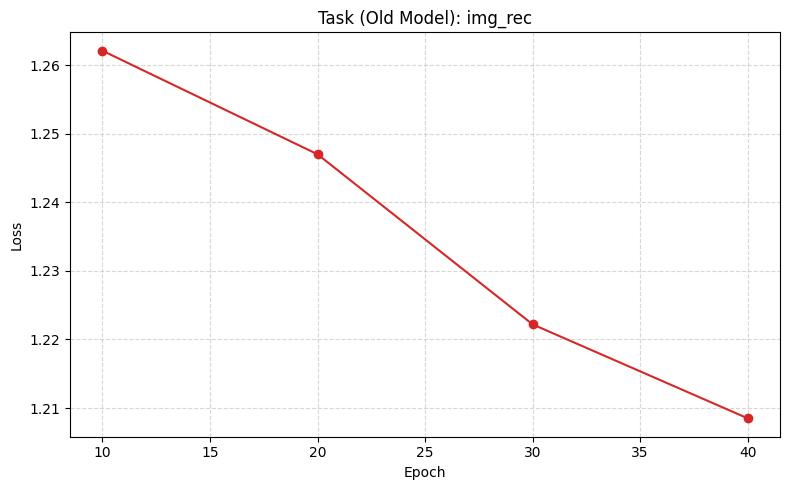

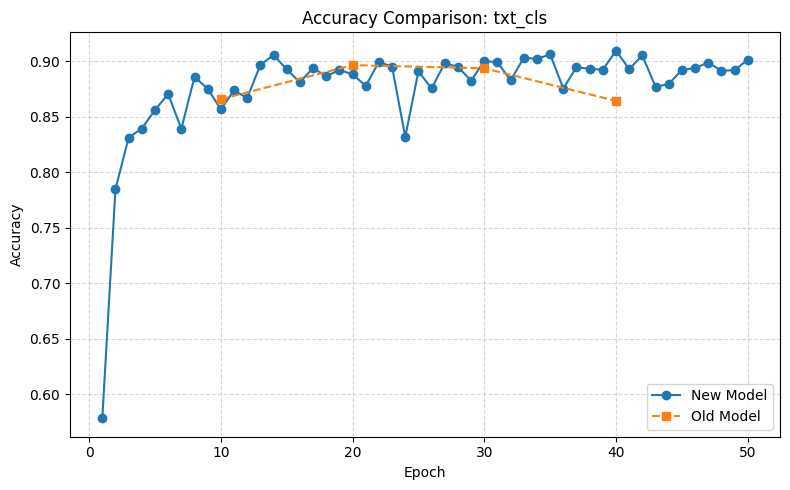

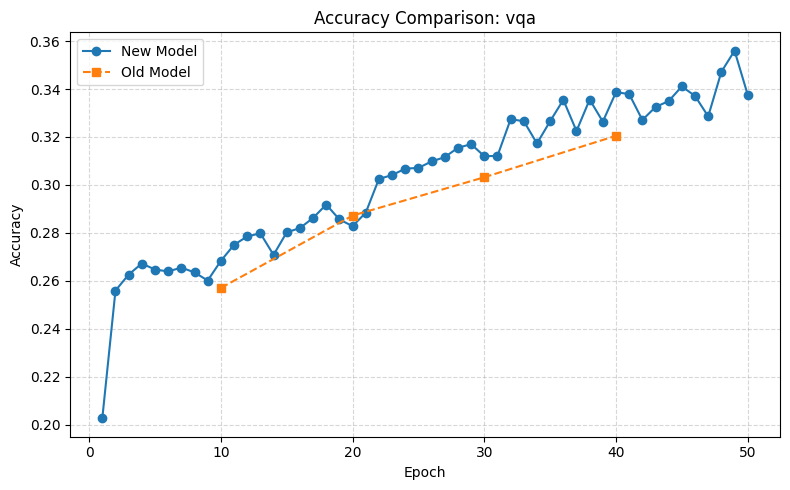

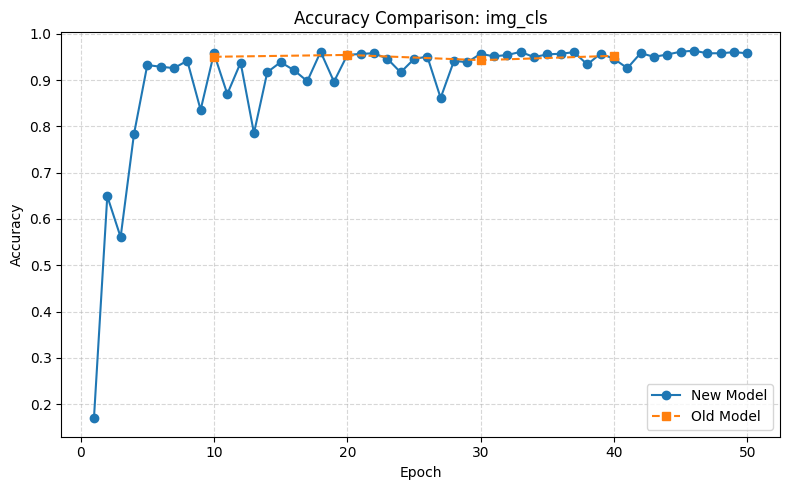

In [2]:
import re
import matplotlib.pyplot as plt

def parse_log(filename, eval_freq=1):
    with open(filename, 'r') as f:
        content = f.read()
    
    # Clean up source artifacts
    content = re.sub(r'\\s*', '', content)
    
    metrics = {
        'txt_rec': {'loss': []},
        'vqa': {'loss': [], 'acc': []},
        'img_cls': {'loss': [], 'acc': []},
        'txt_cls': {'loss': [], 'acc': []},
        'img_rec': {'loss': []}
    }
    
    eval_blocks = re.findall(r'Eval results:(.*?)(?===== Epoch|$)', content, re.DOTALL)
    epochs = []
    
    for i, block in enumerate(eval_blocks):
        epochs.append((i+1) * eval_freq)
        for task in metrics.keys():
            # Find loss
            loss_m = re.search(rf'{task}:.*?loss\s*=\s*([\-\d\.]+)', block, re.DOTALL)
            if loss_m:
                metrics[task]['loss'].append(float(loss_m.group(1)))
                
            # Find accuracy if applicable
            if 'acc' in metrics[task]:
                acc_m = re.search(rf'{task}:.*?acc\s*=\s*([\-\d\.]+)', block, re.DOTALL)
                if acc_m:
                    metrics[task]['acc'].append(float(acc_m.group(1)))
                    
    return epochs, metrics

epochs1, metrics1 = parse_log('./log/main_batch64_20260518_133357.log', eval_freq=1)
epochs2, metrics2 = parse_log('./log/main_newattnlog_20260401_064335.log', eval_freq=10)

# Generate plots for the new model
for task, data in metrics2.items():
    if len(epochs2) == 0 or len(data['loss']) == 0: continue
    
    if 'acc' in data and len(data['acc']) > 0:
        fig, ax1 = plt.subplots(figsize=(8, 5))
        color = 'tab:red'
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color=color)
        ax1.plot(epochs2, data['loss'], color=color, marker='o', label='Loss')
        ax1.tick_params(axis='y', labelcolor=color)
        
        ax2 = ax1.twinx()  
        color = 'tab:blue'
        ax2.set_ylabel('Accuracy', color=color)  
        ax2.plot(epochs2, data['acc'], color=color, marker='s', label='Accuracy')
        ax2.tick_params(axis='y', labelcolor=color)
        
        plt.title(f'Task (Old Model): {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        fig.tight_layout()
        # plt.savefig(f'{task}_new_model.png', dpi=150)
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs2, data['loss'], color='tab:red', marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Task (Old Model): {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        # plt.savefig(f'{task}_new_model.png', dpi=150)
        plt.show()
        # plt.close()

# Generate comparison plots for txt_cls, vqa, img_cls
tasks_to_compare = ['txt_cls', 'vqa', 'img_cls']
for task in tasks_to_compare:
    plt.figure(figsize=(8, 5))
    plt.plot(epochs1, metrics1[task]['acc'], label='New Model', marker='o', linestyle='-', color='tab:blue')
    plt.plot(epochs2, metrics2[task]['acc'], label='Old Model', marker='s', linestyle='--', color='tab:orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Comparison: {task}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f'{task}_comparison.png', dpi=150)
    plt.show()
    # plt.close()